In [1]:
import os
import numpy as np
import keras
from keras import layers
from tensorflow import data as tf_data
import matplotlib.pyplot as plt

2025-03-24 23:14:59.267603: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-24 23:14:59.278871: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742876099.289163   20782 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742876099.292242   20782 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1742876099.301642   20782 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
image_size = (180, 180)
batch_size = 128

train_ds = keras.utils.image_dataset_from_directory(
    "data/4_class_tumors/Training",
    # validation_split=0.2,
    # subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

val_ds = keras.utils.image_dataset_from_directory(
    "data/4_class_tumors/Testing",
    # validation_split=0.2,
    # subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

Found 5712 files belonging to 4 classes.
Found 1311 files belonging to 4 classes.


2025-03-24 23:15:21.867940: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


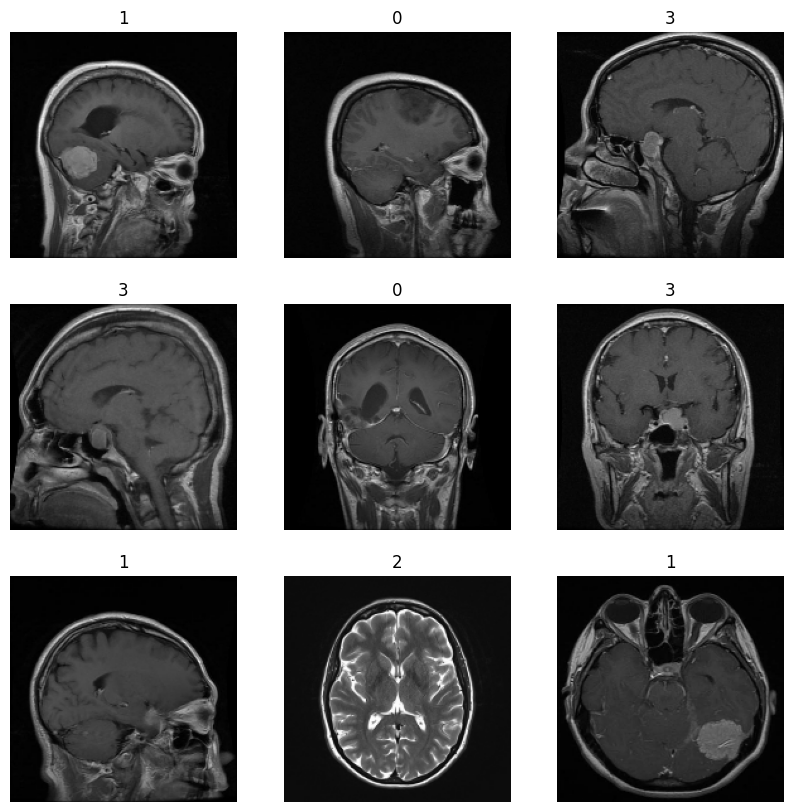

In [4]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

TODO, look in to the validitiy of augmentation, considering the fact that mri images are relativly stable in placement

In [4]:
# data_augmentation_layers = [
#     layers.RandomFlip("horizontal"),
#     layers.RandomRotation(0.1),
# ]


# def data_augmentation(images):
#     for layer in data_augmentation_layers:
#         images = layer(images)
#     return images


In [5]:
# plt.figure(figsize=(10, 10))
# for images, _ in train_ds.take(1):
#     for i in range(9):
#         augmented_images = data_augmentation(images)
#         ax = plt.subplot(3, 3, i + 1)
#         plt.imshow(np.array(augmented_images[0]).astype("uint8"))
#         plt.axis("off")

In [6]:
# # Apply `data_augmentation` to the training images.
# train_ds = train_ds.map(
#     lambda img, label: (data_augmentation(img), label),
#     num_parallel_calls=tf_data.AUTOTUNE,
# )
# # Prefetching samples in GPU memory helps maximize GPU utilization.
# train_ds = train_ds.prefetch(tf_data.AUTOTUNE)
# val_ds = val_ds.prefetch(tf_data.AUTOTUNE)


# MODEL - Xception
https://keras.io/examples/vision/image_classification_from_scratch/

In [5]:
def make_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)

    # Entry block
    x = layers.Rescaling(1.0 / 255)(inputs)
    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    previous_block_activation = x  # Set aside residual

    for size in [256, 512, 728]:
        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

        # Project residual
        residual = layers.Conv2D(size, 1, strides=2, padding="same")(
            previous_block_activation
        )
        x = layers.add([x, residual])  # Add back residual
        previous_block_activation = x  # Set aside next residual

    x = layers.SeparableConv2D(1024, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.25)(x)

    # Output layer with softmax activation for multi-class classification
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs)


model = make_model(input_shape=image_size + (3,), num_classes=4)
keras.utils.plot_model(model, show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [6]:
epochs = 10

callbacks = [
    keras.callbacks.ModelCheckpoint("save_at_{epoch}.keras"),
]
model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.CategoricalAccuracy(name="acc")],
)
model.fit(
    train_ds,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=val_ds,
    verbose=1,
)

Epoch 1/10


/home/ugrads/j/johnslangs/miniconda3/envs/capstone/lib/python3.11/site-packages/keras/src/backend/tensorflow/nn.py:708: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(
I0000 00:00:1742876142.306131   21003 service.cc:152] XLA service 0x7429ac007e80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1742876142.306157   21003 service.cc:160]   StreamExecutor device (0): NVIDIA RTX A2000 12GB, Compute Capability 8.6
2025-03-24 23:15:42.380424: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1742876142.821089   21003 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-03-24 23:16:23.368893: W external/local_xla/xla/tsl/framework/bfc_allocator.cc

44/45 ━━━━━━━━━━━━━━━━━━━━ 0s 727ms/step - acc: 0.1389 - loss: 0.8762

2025-03-24 23:17:20.573114: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3077', 12 bytes spill stores, 12 bytes spill loads



45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.1394 - loss: 0.8718   

2025-03-24 23:18:06.999552: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_335_0', 64 bytes spill stores, 96 bytes spill loads

2025-03-24 23:18:07.005011: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_335', 2920 bytes spill stores, 2916 bytes spill loads

2025-03-24 23:18:07.009113: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_335', 584 bytes spill stores, 584 bytes spill loads

2025-03-24 23:18:09.954622: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_335', 240 bytes spill stores, 288 bytes spill loads

2025-03-24 23:18:10.070023: I exte

45/45 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - acc: 0.1400 - loss: 0.8675 - val_acc: 0.3471 - val_loss: 1.3930
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 35s 782ms/step - acc: 0.1829 - loss: 0.4265 - val_acc: 0.0000e+00 - val_loss: 1.4162
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 35s 783ms/step - acc: 0.1396 - loss: 0.3136 - val_acc: 0.2929 - val_loss: 1.4428
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 35s 784ms/step - acc: 0.1702 - loss: 0.2281 - val_acc: 0.4882 - val_loss: 1.5052
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 35s 786ms/step - acc: 0.1944 - loss: 0.1803 - val_acc: 0.1953 - val_loss: 1.5827
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 35s 786ms/step - acc: 0.2042 - loss: 0.1579 - val_acc: 0.2189 - val_loss: 1.7412
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 35s 787ms/step - acc: 0.1882 - loss: 0.0812 - val_acc: 0.2189 - val_loss: 2.0279
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 35s 787ms/step - acc: 0.1665 - loss: 0.0465 - val_acc: 0.2929 - val_loss: 2.3898
Epoch 9/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 35s 787ms/step - ac